<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import glob
from math import log10, sqrt

Mengubah tingkat kecerahan citra
--------------------------------
Masukan nilai kecerahan: 50


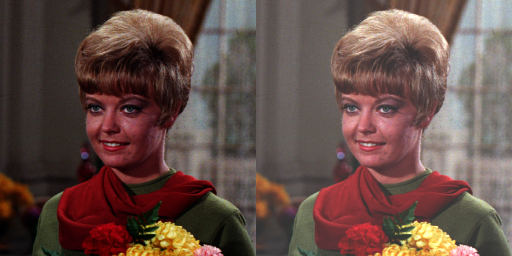

In [61]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

# for y in range(original.shape[0]):
#   for x in range(original.shape[1]):
#     for c in range(original.shape[2]):
#       brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

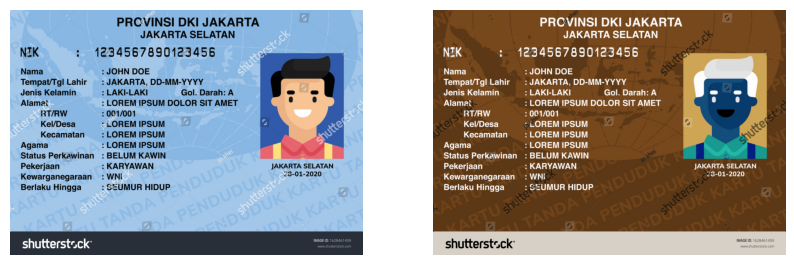

In [62]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')

ktp_rgb = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

# g(x) = 255 - f(x)
ktp_inverted = 255 - ktp_rgb

plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(ktp_rgb)

plt.subplot(1,2,2)
plt.imshow(ktp_inverted)
plt.axis('off')
plt.show()

Mengubah kontras dan tingkat kecerahan citra
-------------------------------------------
Masukan tingkat kecerahan [-255 - 255]: 50
Masukan kontras [1.0 - 3.0]: 2


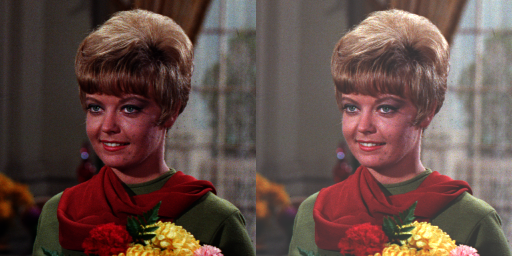

In [63]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-------------------------------------------')

original_image = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')

try:
  brightness = int(input('Masukan tingkat kecerahan [-255 - 255]: '))
  contrast = float(input('Masukan kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error not number')

# calculate contrast (F)
F = 259.0 * (contrast + 255.0) / (255.0 * (259.0 - contrast))

contrasted_image = F * (original_image.astype(float) - 128) + 128 + brightness

contrasted_image = np.clip(contrasted_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat([original_image, contrasted_image])
cv2_imshow(final_frame)

Mengubah tingkat kecerahan citra dengan Transformasi Log
-------------------------------------------------------
Masukan nilai kecerahan: 50


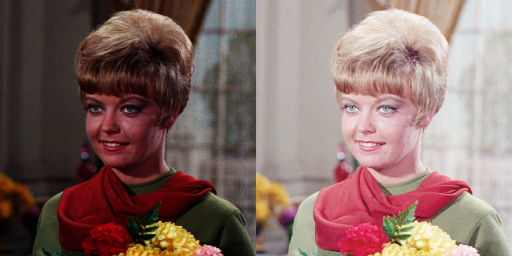

In [64]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-------------------------------------------------------')

try:
  c = float(input('Masukan nilai kecerahan: '))
except ValueError:
  print('Error, not a number. Using default value.')

r = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')

# g(x) = c * log(1 + f(x))
s = c * np.log(1 + r.astype(float))

# normalize 0-255
max_val = np.max(s)
s = (s / max_val) * 255

s = s.astype(np.uint8)

final_frame = cv.hconcat([r, s])
cv2_imshow(final_frame)

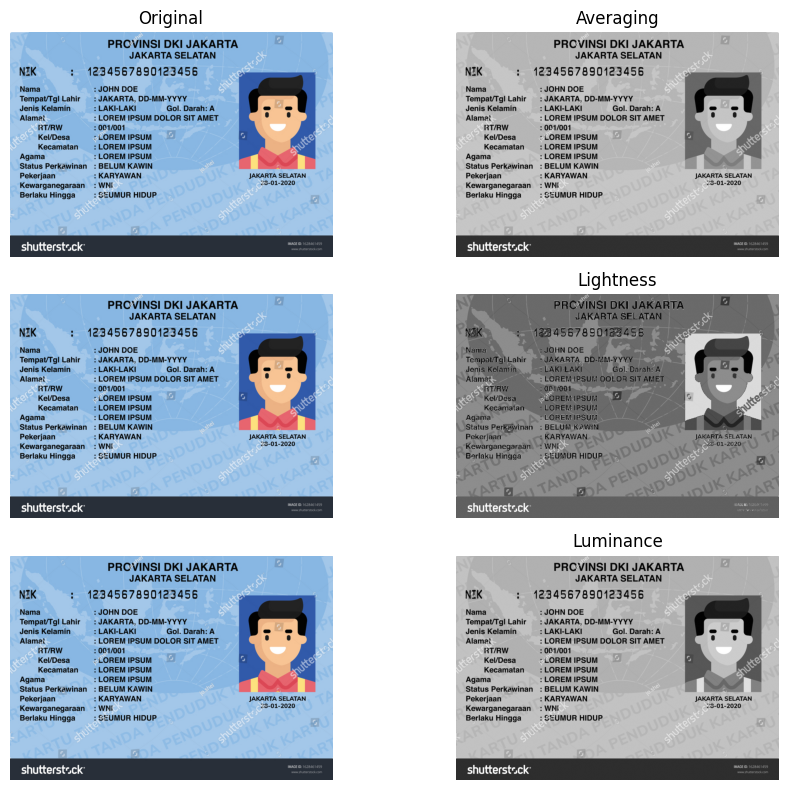

In [65]:
ktp2 = ktp_rgb.copy()

r, g, b = ktp2[:, :, 0], ktp2[:, :, 1], ktp2[:, :, 2]

gray_avg = ((r.astype(float) + g.astype(float) + b.astype(float)) / 3).astype(np.uint8)
gray_lightness = ((np.max(ktp2, axis=2) + np.min(ktp2, axis=2)) / 2).astype(np.uint8)
gray_lum = (0.2126 * r.astype(float) + 0.7152 * g.astype(float) + 0.0722 * b.astype(float)).astype(np.uint8)

plt.figure(figsize=(10, 8))

# averaging
plt.subplot(3, 2, 1)
plt.axis('off')
plt.imshow(ktp2)
plt.title("Original")

plt.subplot(3, 2, 2)
plt.axis('off')
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")

# lightness
plt.subplot(3, 2, 3)
plt.axis('off')
plt.imshow(ktp2)

plt.subplot(3, 2, 4)
plt.axis('off')
plt.imshow(gray_lightness, cmap='gray')
plt.title("Lightness")

# luminance
plt.subplot(3, 2, 5)
plt.axis('off')
plt.imshow(ktp2)

plt.subplot(3, 2, 6)
plt.axis('off')
plt.imshow(gray_lum, cmap='gray')
plt.title("Luminance")

plt.tight_layout()
plt.show()

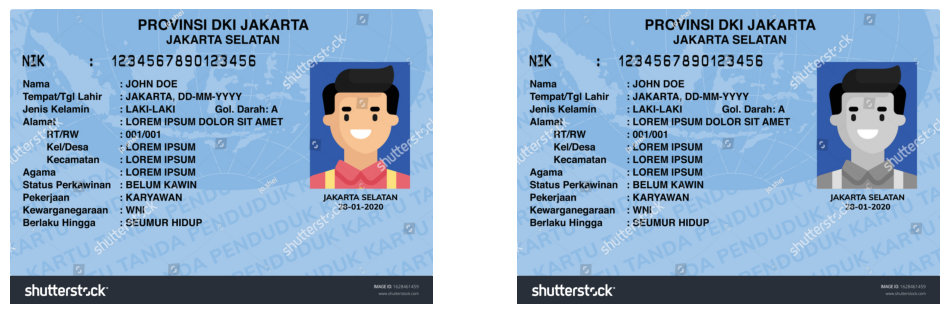

In [66]:
ktp3 = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')
ktp_rgb2 = cv.cvtColor(ktp3, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(ktp_rgb2, cv.COLOR_RGB2GRAY)

gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)
blue_mask = (ktp_rgb2[:, :, 2] > ktp_rgb2[:, :, 0]) & (ktp_rgb2[:, :, 2] > ktp_rgb2[:, :, 1])
color_splash = gray_3ch.copy()
color_splash[blue_mask] = ktp_rgb2[blue_mask]

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(ktp_rgb2)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(color_splash)
plt.axis("off")

plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


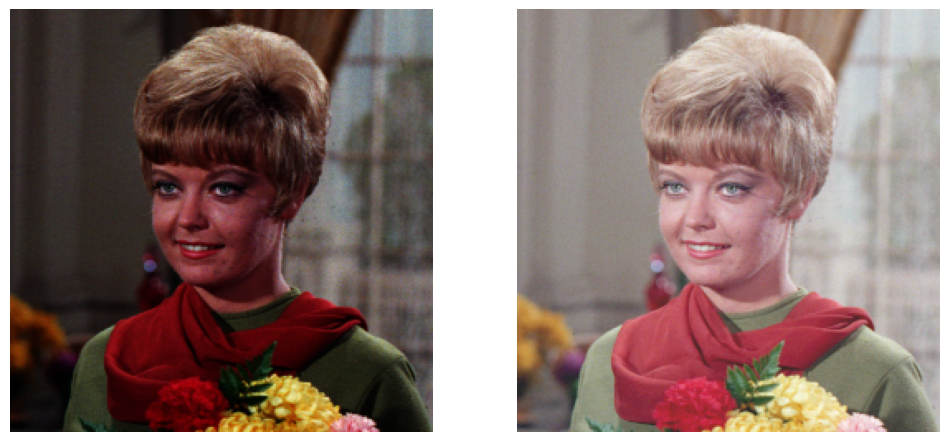

In [67]:
print(' Gamma Correction pada citra ')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

female = cv.imread('/content/drive/MyDrive/PCVK/female.tiff')
female_rgb = cv.cvtColor(female, cv.COLOR_BGR2RGB)

# I' = 255 * (I/255) ** y
inv_gamma = 1.0 / gamma
gamma_corrected = np.array(255 * (female_rgb / 255) ** inv_gamma, dtype='uint8')

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(female_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gamma_corrected)
plt.axis("off")

plt.show()

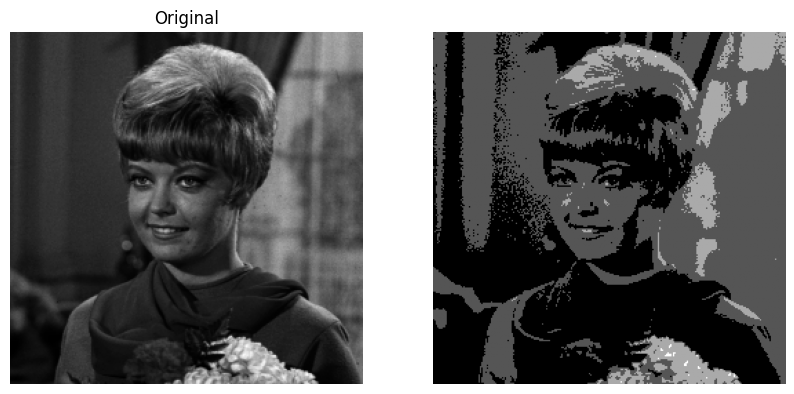

In [68]:
org_img = cv.imread('/content/drive/MyDrive/PCVK/female.tiff', cv.IMREAD_GRAYSCALE)

bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# quantization
quantized = np.round(org_img / level) * level
quantized = quantized.astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(org_img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(quantized, cmap='gray')
plt.axis("off")

plt.show()

Total noisy images loaded: 100
Enter number of noisy images to average: 100
PSNR between Original and Denoised: 27.370931279516654


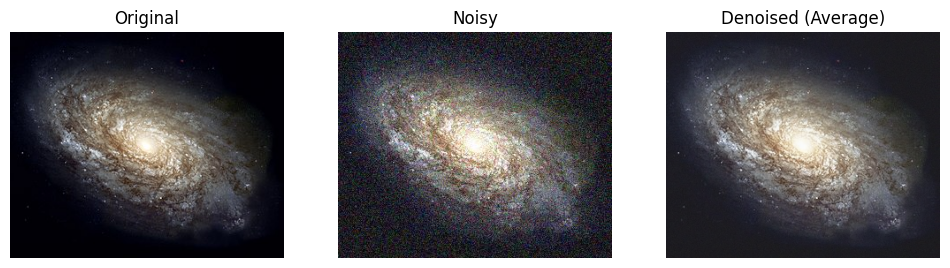

In [69]:
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

original = cv.imread('/content/drive/MyDrive/PCVK/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# noisy images
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/noises/*.jpg'):
    n = cv.imread(img)
    if n is not None:
        n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
        cv_img.append(n)

print(f"Total noisy images loaded: {len(cv_img)}")

try:
    num_images = int(input("Enter number of noisy images to average: "))
except ValueError:
    print("Error: not a number, defaulting to 10")
    num_images = 10

num_images = min(num_images, len(cv_img))

# avg denoising
stacked = np.array(cv_img[:num_images], dtype=np.float32)
denoised = np.mean(stacked, axis=0)
denoised = np.clip(denoised, 0, 255).astype(np.uint8)

# psnr calculation
psnr_value = PSNR(original, denoised)
print("PSNR between Original and Denoised:", psnr_value)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Noisy")
plt.imshow(cv_img[0])
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Denoised (Average)")
plt.imshow(denoised)
plt.axis("off")

plt.show()

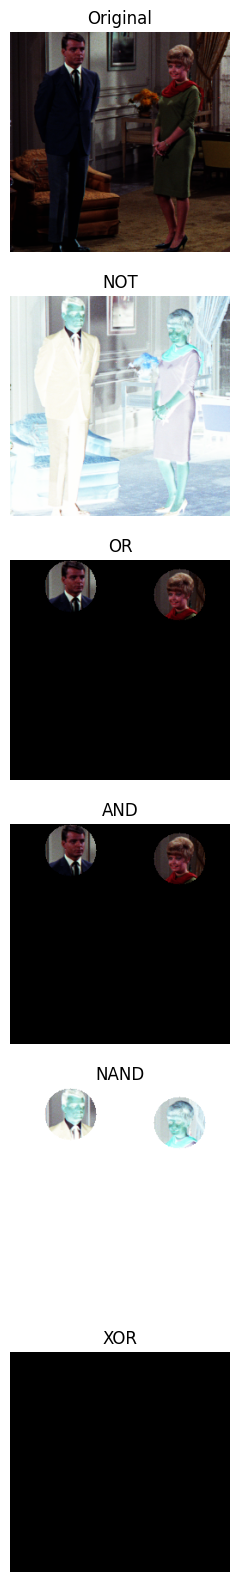

In [72]:
img_couple = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/couple.tiff'), cv.COLOR_BGR2RGB)

canvas = np.zeros((img_couple.shape[0], img_couple.shape[1]), dtype=np.uint8)

cv.circle(canvas, center=(70,30), radius=30, color=(255,255,255), thickness=-1)
cv.circle(canvas, center=(197,40), radius=30, color=(255,255,255), thickness=-1)

result = cv.bitwise_not(img_couple)
result2 = cv.bitwise_or(img_couple, img_couple,mask = canvas)
result3 = cv.bitwise_and(img_couple, img_couple,mask = canvas)
result4 = cv.bitwise_not(result3)
result5 = cv.bitwise_xor(img_couple, img_couple,mask = canvas)

plt.figure(figsize=(10,20))

plt.subplot(6,1,1)
plt.title('Original')
plt.axis('off')
plt.imshow(img_couple)

plt.subplot(6,1,2)
plt.title('NOT')
plt.axis('off')
plt.imshow(result)

plt.subplot(6,1,3)
plt.title('OR')
plt.axis('off')
plt.imshow(result2)

plt.subplot(6,1,4)
plt.title('AND')
plt.axis('off')
plt.imshow(result3)

plt.subplot(6,1,5)
plt.title('NAND')
plt.axis('off')
plt.imshow(result4)

plt.subplot(6,1,6)
plt.title('XOR')
plt.axis('off')
plt.imshow(result5)

plt.show()